GIAI ĐOẠN 1: LGBM BASELINE
Đang đọc, trích xuất Hình học, HOG, Color Histogram và LBP...
Đang chia tập dữ liệu đảm bảo Cân bằng Class và Chống Leakage...
Kích thước X_train: (12950, 2567)
Kích thước X_val:   (2796, 2567)
Kích thước X_test:  (2799, 2567)
Xử lý dữ liệu hoàn tất!

Đang huấn luyện...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.519907 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 626480
[LightGBM] [Info] Number of data points in the train set: 12950, number of used features: 2524
[LightGBM] [Info] Start training from score -1.952962
[LightGBM] [Info] Start training from score -1.812987
[LightGBM] [Info] Start training from score -1.996350
[LightGBM] [Info] Start training from score -1.969981
[LightGBM] [Info] Start training from score -1.953506
[LightGBM] [Info] Start training from score -1.964460
[LightGBM] [Info] Start training from score -1.982798
Training until validation score

d:\HOC_TREN_TRUONG\TU_DUY_TINH_TOAN\DO_AN\Coffee-Beans-Quality-Ranking\ds107\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Thời gian dự đoán (Inference Time): 0.5634 giây

--- ĐÁNH GIÁ (MACRO) ---
Precision: 0.8154
Recall:    0.8166
F1-score:  0.8134

--- ĐÁNH GIÁ (WEIGHTED) ---
Precision: 0.8165
Recall:    0.8119
F1-score:  0.8113

--- TỔNG QUAN ---
Accuracy:  0.8119

--- ĐỘ CHÍNH XÁC TỪNG LỚP ---
              precision    recall  f1-score   support

           0       0.68      0.72      0.70       360
           1       0.82      0.69      0.75       502
           2       0.74      0.91      0.82       401
           3       0.95      0.87      0.91       403
           4       0.90      0.95      0.92       360
           5       0.81      0.78      0.80       351
           6       0.81      0.79      0.80       419

    accuracy                           0.81      2796
   macro avg       0.82      0.82      0.81      2796
weighted avg       0.82      0.81      0.81      2796


--- ĐANG HIỂN THỊ ĐỒ THỊ BASELINE ---


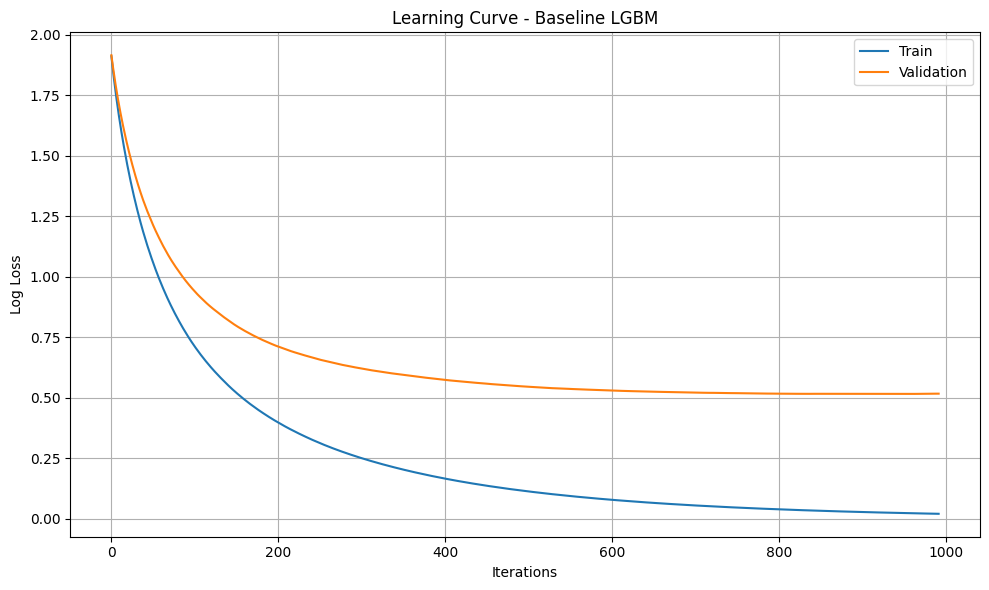

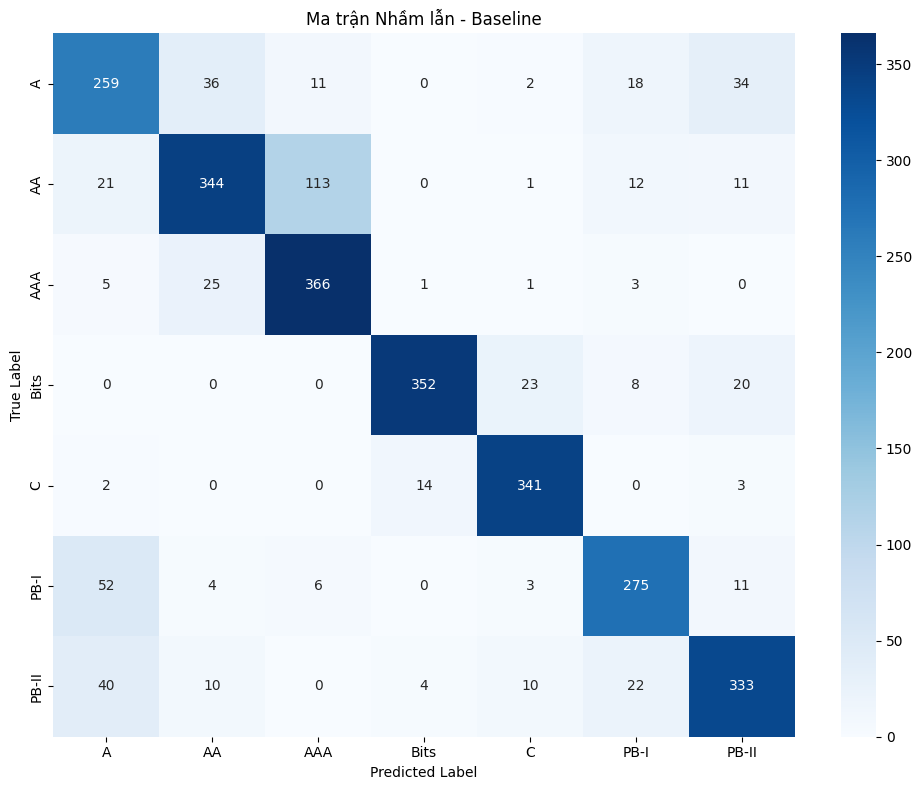


[SHAP] Đang tính SHAP (native LGBM)...


d:\HOC_TREN_TRUONG\TU_DUY_TINH_TOAN\DO_AN\Coffee-Beans-Quality-Ranking\ds107\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


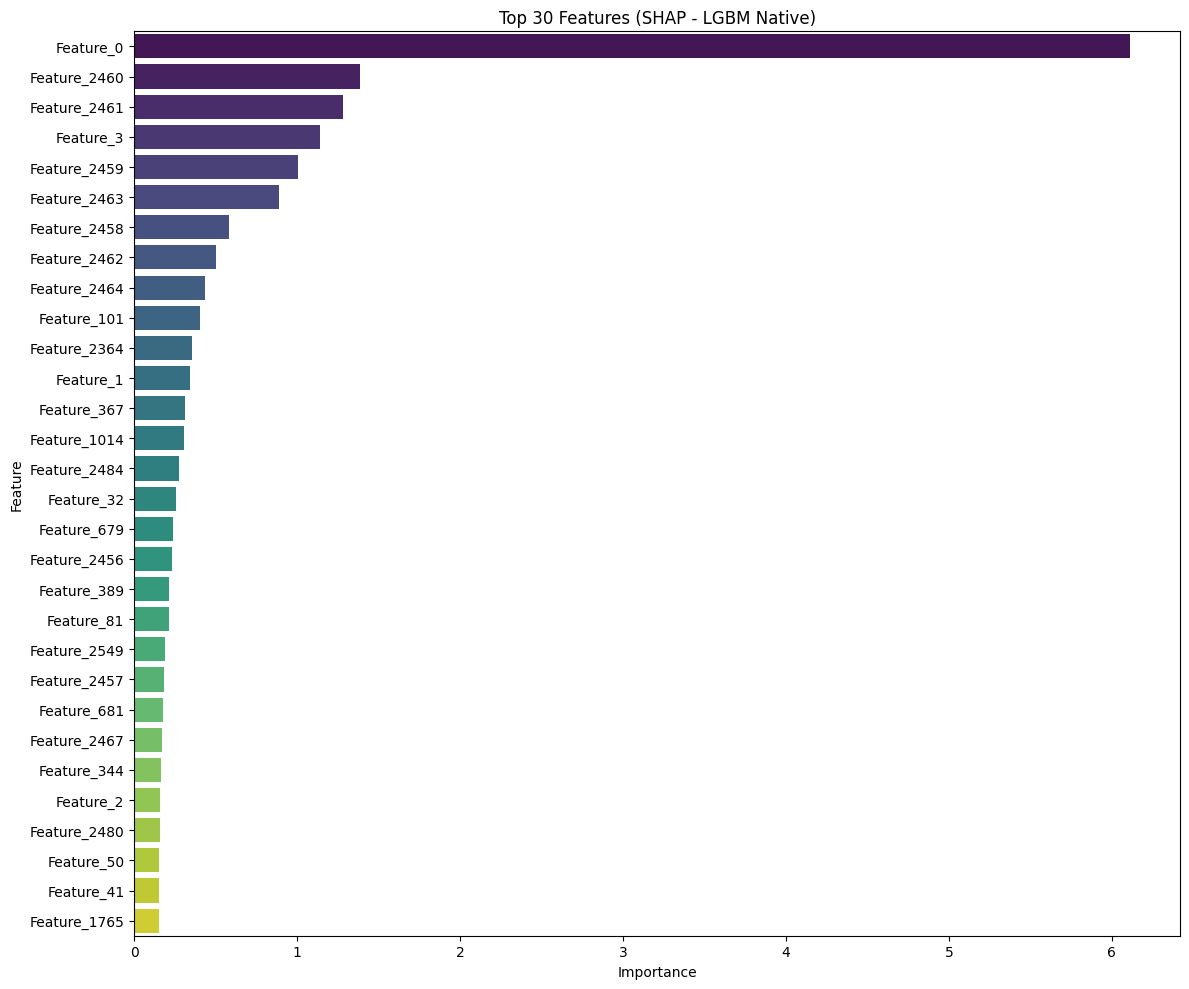

-> SHAP done in 40.95s


In [ ]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix
from Data_preprocessing_CBD import data_preprocessing

# =====================================================================
# UTILITIES
# =====================================================================

def plot_confusion_matrix(y_true, y_pred, target_names, title='Confusion Matrix - LGBM'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_loss_curve(model, title='Learning Curve - LGBM'):
    results = model.evals_result_
    print('OK1')
    train_loss = results['training']['multi_logloss']
    val_loss = results['valid_1']['multi_logloss']
    print('OK2')
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Train')
    plt.plot(val_loss, label='Validation')
    plt.legend()
    plt.title(title)
    plt.xlabel('Iterations')
    plt.ylabel('Log Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =====================================================================
# NATIVE SHAP LIGHTGBM (QUAN TRỌNG)
# =====================================================================

def get_shap_feature_importance_lgbm(model, X_train, X_val, top_n=30):
    print(f"\n[SHAP] Đang tính SHAP (native LGBM)...")
    start = time.time()

    # Native SHAP
    shap_values = model.predict(X_val, pred_contrib=True)

    n_samples = X_val.shape[0]
    n_features = X_val.shape[1]
    n_classes = model.n_classes_

    # reshape: (samples, classes, features+1)
    shap_values = shap_values.reshape(n_samples, n_classes, n_features + 1)

    # bỏ base value
    shap_values = shap_values[:, :, :-1]

    # gộp multi-class giống CatBoost
    shap_importance = np.abs(shap_values).mean(axis=0).sum(axis=0)

    if hasattr(X_train, 'columns'):
        feature_names = X_train.columns
    else:
        feature_names = [f'Feature_{i}' for i in range(n_features)]

    feature_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': shap_importance
    }).sort_values(by='Importance', ascending=False)

    top_features = feature_imp_df.head(top_n)

    plt.figure(figsize=(12, 10))
    sns.barplot(x='Importance', y='Feature', data=top_features,
                hue='Feature', palette='viridis', legend=False)
    plt.title(f'Top {top_n} Features (SHAP - LGBM Native)')
    plt.tight_layout()
    plt.show()

    print(f"-> SHAP done in {time.time() - start:.2f}s")
    return feature_imp_df

# =====================================================================
# STAGE 1: BASELINE
# =====================================================================

print("="*50)
print("GIAI ĐOẠN 1: LGBM BASELINE")
print("="*50)

X_train, y_train, X_val, y_val, X_test, y_test = data_preprocessing(base_folder=r'data/CBD')

target_names = ["A", "AA", "AAA", "Bits", "C", "PB-I", "PB-II"]

model_baseline = lgb.LGBMClassifier(
    n_estimators=5000,       # Tăng số cây lên mức trần, có early stopping lo việc tự ngắt
    learning_rate=0.01,
    importance_type='gain',
    random_state=42,
    n_jobs=-1
)

print("\nĐang huấn luyện...")
model_baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='multi_logloss',
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(200)
    ]
)

# Predict
start_time = time.time()
y_pred_base = model_baseline.predict(X_val).flatten() 
end_time = time.time()
    
predict_time = end_time - start_time

print(f"Thời gian dự đoán (Inference Time): {predict_time:.4f} giây")

# Evaluation
print("\n--- ĐÁNH GIÁ (MACRO) ---")
print(f"Precision: {precision_score(y_val, y_pred_base, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_base, average='macro'):.4f}")
print(f"F1-score:  {f1_score(y_val, y_pred_base, average='macro'):.4f}")

print("\n--- ĐÁNH GIÁ (WEIGHTED) ---")
print(f"Precision: {precision_score(y_val, y_pred_base, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_base, average='weighted'):.4f}")
print(f"F1-score:  {f1_score(y_val, y_pred_base, average='weighted'):.4f}")

print("\n--- TỔNG QUAN ---")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_base):.4f}")

print("\n--- ĐỘ CHÍNH XÁC TỪNG LỚP ---")
print(classification_report(y_val, y_pred_base))

print("\n--- ĐANG HIỂN THỊ ĐỒ THỊ BASELINE ---")
plot_loss_curve(model_baseline, title='Learning Curve - Baseline LGBM')
plot_confusion_matrix(y_val, y_pred_base, target_names, title='Ma trận Nhầm lẫn - Baseline')
# SHAP
all_importances_shap = get_shap_feature_importance_lgbm(
    model_baseline, X_train, X_val, top_n=30
)


GIAI ĐOẠN 2: RETRAIN

TOP 500 FEATURES
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033879 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127500
[LightGBM] [Info] Number of data points in the train set: 12950, number of used features: 500
[LightGBM] [Info] Start training from score -1.952962
[LightGBM] [Info] Start training from score -1.812987
[LightGBM] [Info] Start training from score -1.996350
[LightGBM] [Info] Start training from score -1.969981
[LightGBM] [Info] Start training from score -1.953506
[LightGBM] [Info] Start training from score -1.964460
[LightGBM] [Info] Start training from score -1.982798
Training until validation scores don't improve for 50 rounds
[50]	training's multi_logloss: 1.07363	valid_1's multi_logloss: 1.21857
[100]	training's multi_logloss: 0.72499	valid_1's multi_logloss: 0.938373
[150]	training's multi_logloss: 0.534458	valid_1's multi_logloss: 0.794621
[200]	tr

d:\HOC_TREN_TRUONG\TU_DUY_TINH_TOAN\DO_AN\Coffee-Beans-Quality-Ranking\ds107\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- ĐÁNH GIÁ MÔ HÌNH MỚI (TOP 500 FEATURES) ---
Thời gian dự đoán (Inference Time): 0.4461 giây

--- MACRO ---
Accuracy:  0.8079
Precision: 0.8113
Recall:    0.8124
F1-score:  0.8099

--- WEIGHTED ---
Precision: 0.8117
Recall:    0.8079
F1-score:  0.8077

--- TỔNG QUAN ---
Accuracy:  0.8079

--- ĐỘ CHÍNH XÁC TỪNG LỚP ---
              precision    recall  f1-score   support

           0       0.67      0.71      0.69       360
           1       0.80      0.69      0.74       502
           2       0.74      0.89      0.81       401
           3       0.95      0.88      0.91       403
           4       0.91      0.95      0.93       360
           5       0.80      0.78      0.79       351
           6       0.81      0.80      0.80       419

    accuracy                           0.81      2796
   macro avg       0.81      0.81      0.81      2796
weighted avg       0.81      0.81      0.81      2796



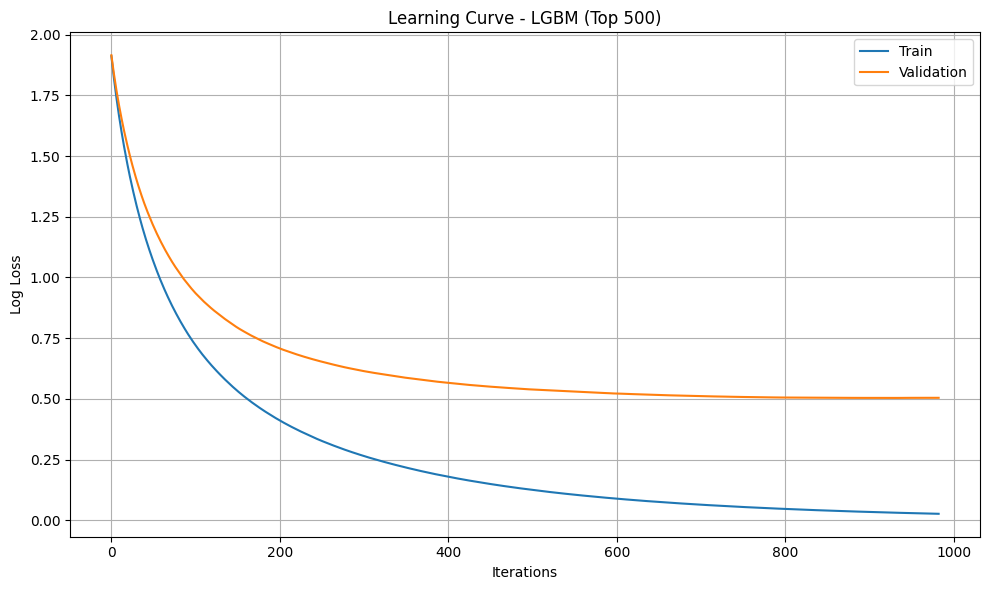

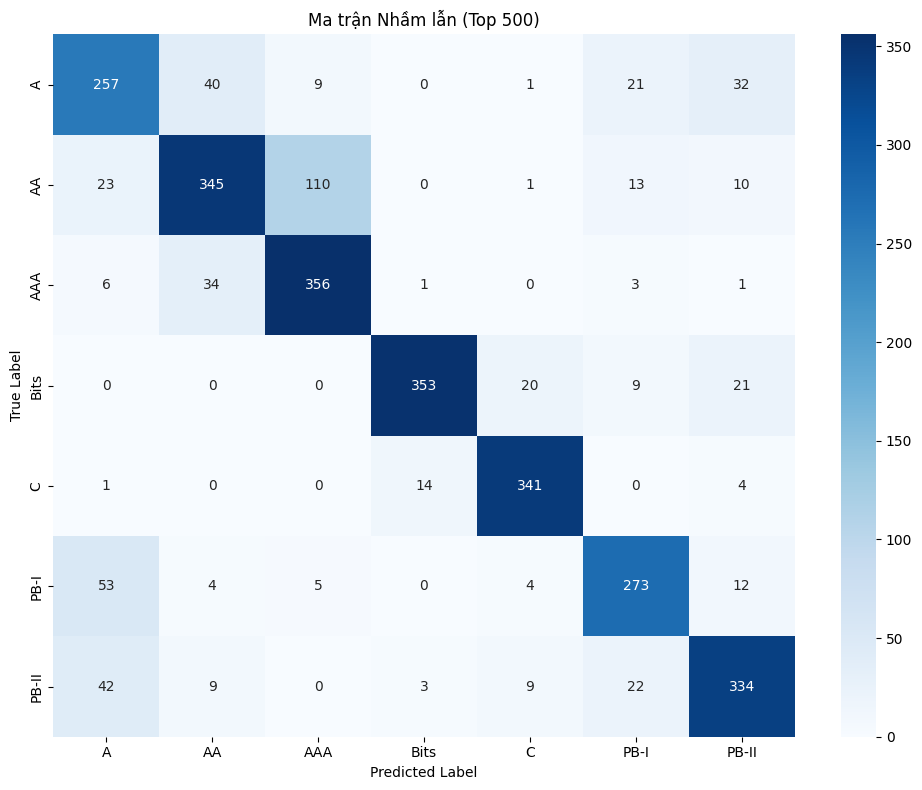


TOP 1000 FEATURES
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.111745 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 254983
[LightGBM] [Info] Number of data points in the train set: 12950, number of used features: 1000
[LightGBM] [Info] Start training from score -1.952962
[LightGBM] [Info] Start training from score -1.812987
[LightGBM] [Info] Start training from score -1.996350
[LightGBM] [Info] Start training from score -1.969981
[LightGBM] [Info] Start training from score -1.953506
[LightGBM] [Info] Start training from score -1.964460
[LightGBM] [Info] Start training from score -1.982798
Training until validation scores don't improve for 50 rounds
[50]	training's multi_logloss: 1.06924	valid_1's multi_logloss: 1.21921
[100]	training's multi_logloss: 0.718986	valid_1's multi_logloss: 0.939148
[150]	training's multi_logloss: 0.526438	valid_1's multi_logloss: 0.793584
[200]	training's multi_logl

d:\HOC_TREN_TRUONG\TU_DUY_TINH_TOAN\DO_AN\Coffee-Beans-Quality-Ranking\ds107\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- ĐÁNH GIÁ MÔ HÌNH MỚI (TOP 1000 FEATURES) ---
Thời gian dự đoán (Inference Time): 0.3719 giây

--- MACRO ---
Accuracy:  0.8122
Precision: 0.8157
Recall:    0.8164
F1-score:  0.8138

--- WEIGHTED ---
Precision: 0.8166
Recall:    0.8122
F1-score:  0.8120

--- TỔNG QUAN ---
Accuracy:  0.8122

--- ĐỘ CHÍNH XÁC TỪNG LỚP ---
              precision    recall  f1-score   support

           0       0.68      0.72      0.70       360
           1       0.82      0.70      0.75       502
           2       0.74      0.91      0.82       401
           3       0.95      0.87      0.91       403
           4       0.90      0.94      0.92       360
           5       0.82      0.79      0.80       351
           6       0.80      0.79      0.80       419

    accuracy                           0.81      2796
   macro avg       0.82      0.82      0.81      2796
weighted avg       0.82      0.81      0.81      2796



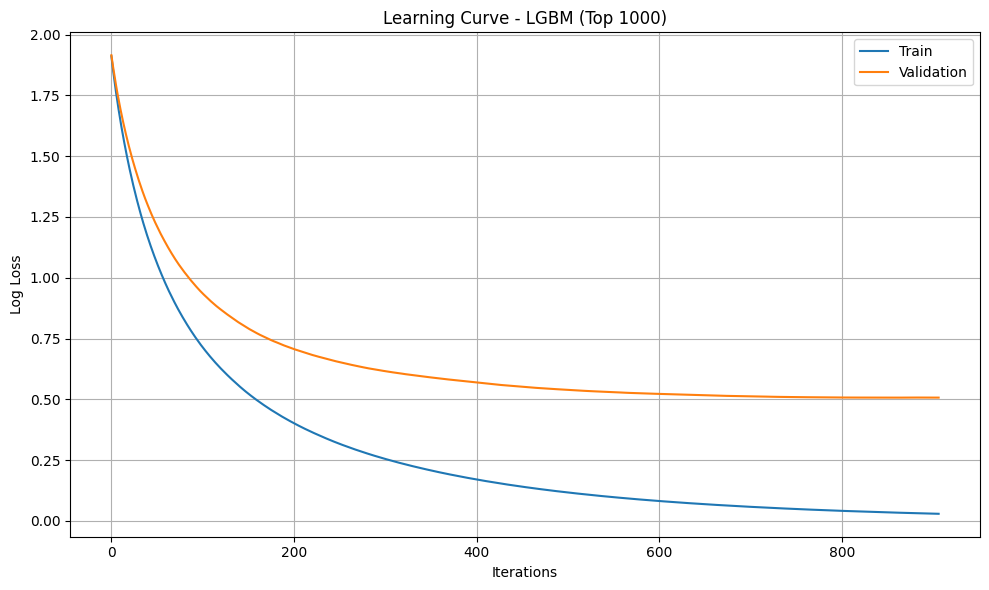

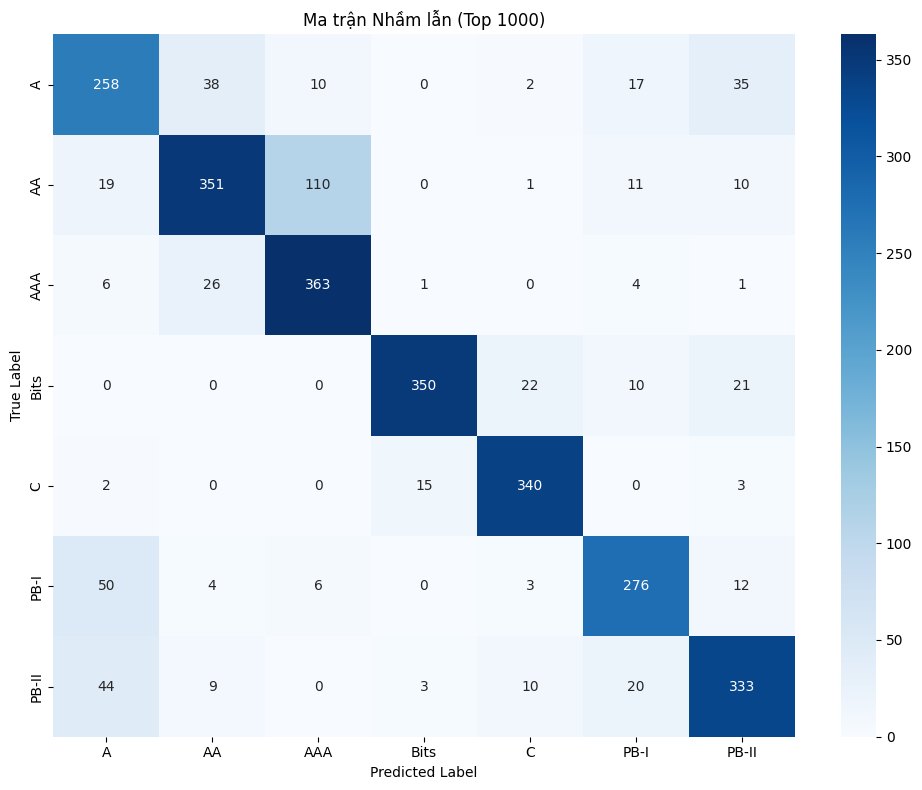


TOP 1500 FEATURES
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.191887 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 382314
[LightGBM] [Info] Number of data points in the train set: 12950, number of used features: 1500
[LightGBM] [Info] Start training from score -1.952962
[LightGBM] [Info] Start training from score -1.812987
[LightGBM] [Info] Start training from score -1.996350
[LightGBM] [Info] Start training from score -1.969981
[LightGBM] [Info] Start training from score -1.953506
[LightGBM] [Info] Start training from score -1.964460
[LightGBM] [Info] Start training from score -1.982798
Training until validation scores don't improve for 50 rounds
[50]	training's multi_logloss: 1.06849	valid_1's multi_logloss: 1.21994
[100]	training's multi_logloss: 0.717194	valid_1's multi_logloss: 0.940844
[150]	training's multi_logloss: 0.524244	valid_1's multi_logloss: 0.797648
[200]	training's multi_logl

d:\HOC_TREN_TRUONG\TU_DUY_TINH_TOAN\DO_AN\Coffee-Beans-Quality-Ranking\ds107\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- ĐÁNH GIÁ MÔ HÌNH MỚI (TOP 1500 FEATURES) ---
Thời gian dự đoán (Inference Time): 0.3940 giây

--- MACRO ---
Accuracy:  0.8097
Precision: 0.8135
Recall:    0.8143
F1-score:  0.8115

--- WEIGHTED ---
Precision: 0.8143
Recall:    0.8097
F1-score:  0.8094

--- TỔNG QUAN ---
Accuracy:  0.8097

--- ĐỘ CHÍNH XÁC TỪNG LỚP ---
              precision    recall  f1-score   support

           0       0.68      0.71      0.70       360
           1       0.82      0.69      0.75       502
           2       0.73      0.90      0.81       401
           3       0.94      0.88      0.91       403
           4       0.90      0.94      0.92       360
           5       0.81      0.79      0.80       351
           6       0.81      0.79      0.80       419

    accuracy                           0.81      2796
   macro avg       0.81      0.81      0.81      2796
weighted avg       0.81      0.81      0.81      2796



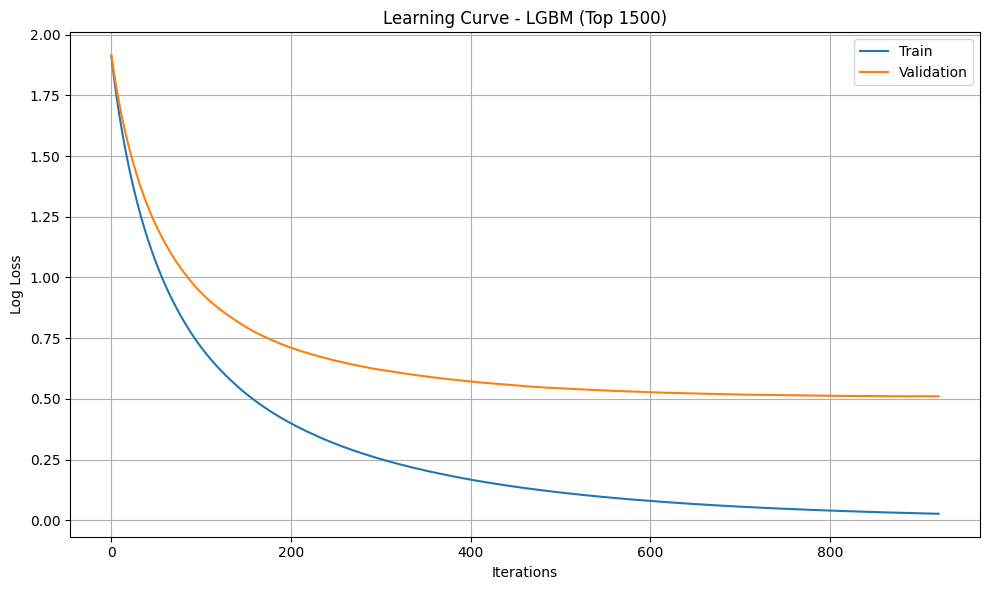

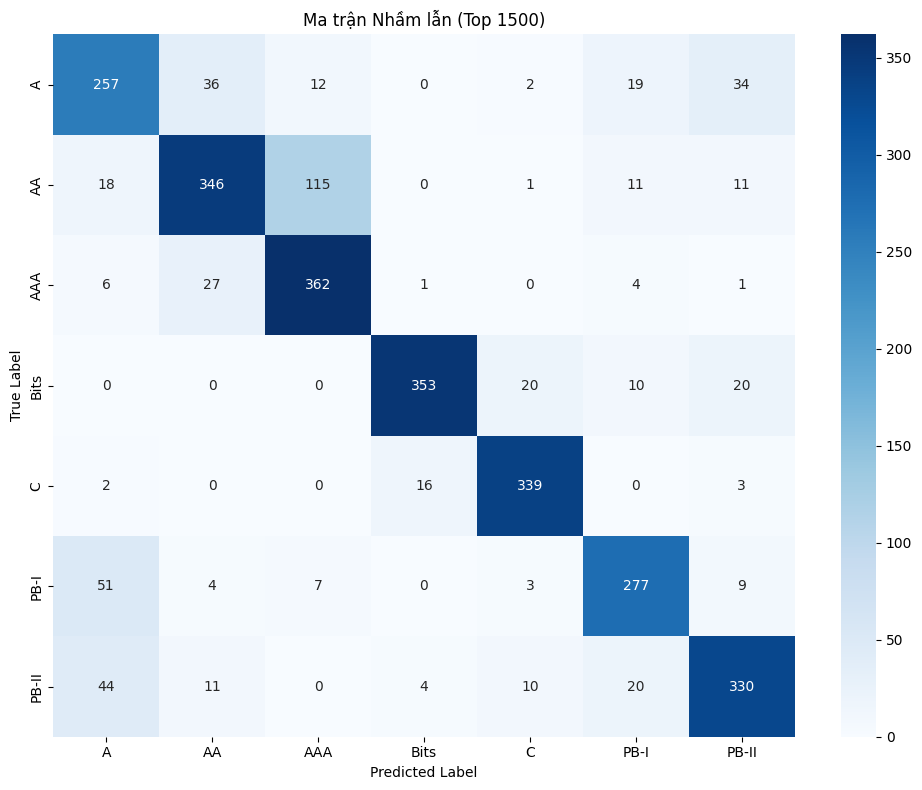

In [2]:
# =====================================================================
# STAGE 2: RETRAIN
# =====================================================================

print("\n" + "="*50)
print("GIAI ĐOẠN 2: RETRAIN")
print("="*50)

top_ns = [500, 1000, 1500]

for top_n in top_ns:
    print(f"\nTOP {top_n} FEATURES")

    important_features = all_importances_shap.head(top_n)

    if hasattr(X_train, 'columns'):
        selected_cols = important_features['Feature'].tolist()
        X_train_red = X_train[selected_cols]
        X_val_red   = X_val[selected_cols]
        X_test_red  = X_test[selected_cols]
    else:
        selected_idx = [int(f.split('_')[1]) for f in important_features['Feature']]
        X_train_red = X_train[:, selected_idx]
        X_val_red   = X_val[:, selected_idx]
        X_test_red  = X_test[:, selected_idx]

    model_final = lgb.LGBMClassifier(
        n_estimators=5000,       # Tăng số cây lên mức trần, có early stopping lo việc tự ngắt
        learning_rate=0.01,
        importance_type='gain',
        random_state=42,
        n_jobs=-1
    )

    model_final.fit(
        X_train_red, y_train,
        eval_set=[(X_train_red, y_train), (X_val_red, y_val)],
        eval_metric='multi_logloss',
        callbacks=[
            lgb.early_stopping(50),
            lgb.log_evaluation(50)
        ]
    )

    start = time.time()
    y_pred_final = model_final.predict(X_val_red)
    predict_time = time.time() - start

    print(f"\n--- ĐÁNH GIÁ MÔ HÌNH MỚI (TOP {top_n} FEATURES) ---")
    print(f"Thời gian dự đoán (Inference Time): {predict_time:.4f} giây")

    print("\n--- MACRO ---")
    print(f"Accuracy:  {accuracy_score(y_val, y_pred_final):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred_final, average='macro'):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_final, average='macro'):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_final, average='macro'):.4f}")

    print("\n--- WEIGHTED ---")
    print(f"Precision: {precision_score(y_val, y_pred_final, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_final, average='weighted'):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_final, average='weighted'):.4f}")
    print("\n--- TỔNG QUAN ---")
    print(f"Accuracy:  {accuracy_score(y_val, y_pred_final):.4f}")
    print("\n--- ĐỘ CHÍNH XÁC TỪNG LỚP ---")
    print(classification_report(y_val, y_pred_final))
    
    # Vẽ đồ thị cho từng mô hình cắt giảm
    plot_loss_curve(model_final, title=f'Learning Curve - LGBM (Top {top_n})')
    plot_confusion_matrix(y_val, y_pred_final, target_names, title=f'Ma trận Nhầm lẫn (Top {top_n})')

### Predict

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.098128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255000
[LightGBM] [Info] Number of data points in the train set: 15746, number of used features: 1000
[LightGBM] [Info] Start training from score -1.969494
[LightGBM] [Info] Start training from score -1.795322
[LightGBM] [Info] Start training from score -1.986478
[LightGBM] [Info] Start training from score -1.964046
[LightGBM] [Info] Start training from score -1.969949
[LightGBM] [Info] Start training from score -1.983243
[LightGBM] [Info] Start training from score -1.967220


d:\HOC_TREN_TRUONG\TU_DUY_TINH_TOAN\DO_AN\Coffee-Beans-Quality-Ranking\ds107\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- ĐÁNH GIÁ MÔ HÌNH MỚI (TOP 1000 FEATURES) ---
Thời gian dự đoán (Inference Time): 0.5558 giây

--- MACRO ---
Accuracy:  0.8474
Precision: 0.8457
Recall:    0.8511
F1-score:  0.8467

--- WEIGHTED ---
Precision: 0.8473
Recall:    0.8474
F1-score:  0.8457

--- TỔNG QUAN ---
Accuracy:  0.8474

--- ĐỘ CHÍNH XÁC TỪNG LỚP ---
              precision    recall  f1-score   support

           0       0.79      0.70      0.74       412
           1       0.83      0.74      0.78       461
           2       0.79      0.92      0.85       354
           3       0.92      0.98      0.95       406
           4       0.96      0.94      0.95       411
           5       0.84      0.81      0.83       403
           6       0.81      0.86      0.83       352

    accuracy                           0.85      2799
   macro avg       0.85      0.85      0.85      2799
weighted avg       0.85      0.85      0.85      2799



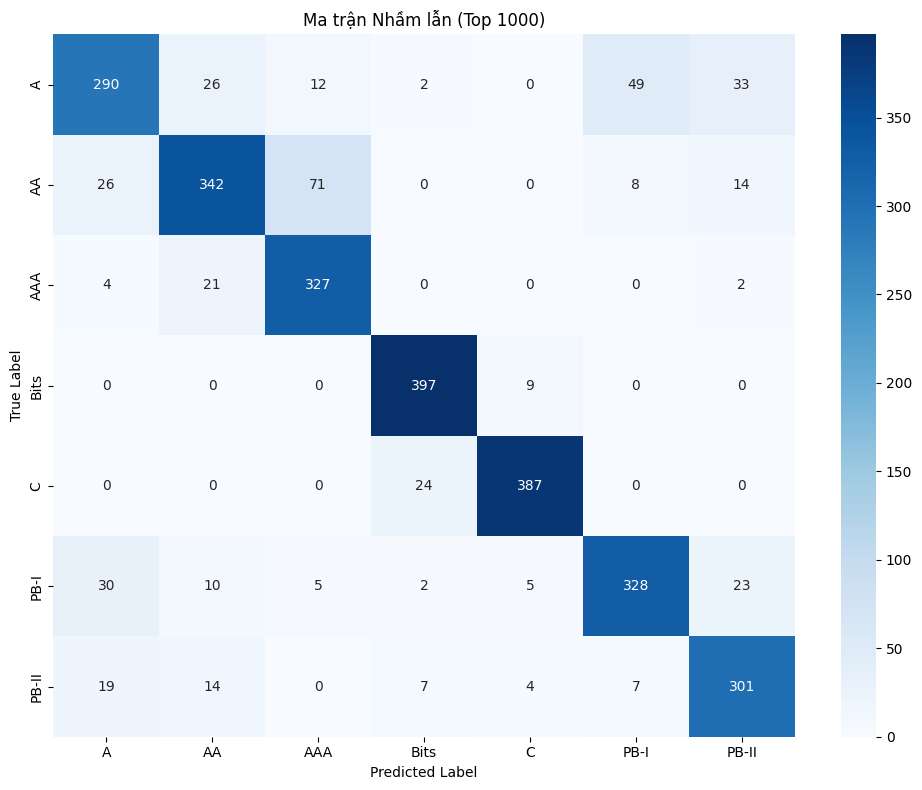

In [26]:
top_n = 1000
important_features = all_importances_shap.head(top_n)

if hasattr(X_train, 'columns'):
    selected_cols = important_features['Feature'].tolist()
    X_train_red = X_train[selected_cols]
    X_val_red   = X_val[selected_cols]
    X_test_red  = X_test[selected_cols]
else:
    selected_idx = [int(f.split('_')[1]) for f in important_features['Feature']]
    X_train_red = X_train[:, selected_idx]
    X_val_red   = X_val[:, selected_idx]
    X_test_red  = X_test[:, selected_idx]

model_final = lgb.LGBMClassifier(
    n_estimators=857,       # Thay đổi số cây
    learning_rate=0.01,
    importance_type='gain',
    random_state=42,
    n_jobs=-1
)

X_train_red_cp = np.vstack([X_train_red, X_val_red])
y_train_cp = np.concatenate([y_train, y_val]) 
model_final.fit(
    X_train_red_cp, y_train_cp
)

# Predict trên Test
start = time.time()
y_pred_test = model_final.predict(X_test_red)
predict_time = time.time() - start

print(f"\n--- ĐÁNH GIÁ MÔ HÌNH MỚI (TOP {top_n} FEATURES) ---")
print(f"Thời gian dự đoán (Inference Time): {predict_time:.4f} giây")

print("\n--- MACRO ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test, average='macro'):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_test, average='macro'):.4f}")

print("\n--- WEIGHTED ---")
print(f"Precision: {precision_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_test, average='weighted'):.4f}")
print("\n--- TỔNG QUAN ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print("\n--- ĐỘ CHÍNH XÁC TỪNG LỚP ---")
print(classification_report(y_test, y_pred_test))

plot_confusion_matrix(y_test, y_pred_test, target_names, title=f'Ma trận Nhầm lẫn (Top {top_n})')